In [ ]:
%pip install --upgrade pip
%pip install tensorflow tensorboard scikit-learn matplotlib numpy opencv-python keras-tuner

# Task 3: Building the Neural Network Architecture Model

## Introduction

The following notebook contains the architecture, hyperparameter tuning, training, and evaluation code for the final VGG-inspired CNN model. Project information, dependencies, file descriptions, and execution instructions can be found in the accompanying README file. 

This notebook is organized according to the development workflow, which does not match the order of Parts B-E of Task 3. Because of this, questions are answered alongside the relevant code cells. Part C is answered under model architecture, Part E under hyperparameter tuning, and Parts B and D under model summary.

To improve readability and avoid the presence of extraneous information, this notebook has been streamlined from the original file to include only the code, outputs, and visualizations needed to satisfy the assessment requirements. Details concerning previous model versions, refinements, and performance analysis can be found in Task 4.

NOTE: As Bayesian optimization and training took over 16 hours to complete, please use the saved model loading cell at the end of this notebook for verification.

## Import Libraries

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import (Dense, Conv2D, MaxPooling2D, Dropout, Input, 
                          RandomFlip, RandomRotation, RandomZoom, RandomContrast, 
                          BatchNormalization, GlobalAveragePooling2D)
from keras.metrics import Precision, Recall
import keras.backend as K
import keras_tuner as kt
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

## Load Data

As the clean data from Task 2 was saved as unsigned 8-bit image arrays, we must convert them back to float32 in addition to loading the data.

In [ ]:
data = np.load('cifar10_clean.npz')

X_train = data['X_train'].astype('float32') / 255.0
X_val = data['X_val'].astype('float32') / 255.0
X_test = data['X_test'].astype('float32') / 255.0

y_train = data['y_train'].astype('float32')
y_val = data['y_val'].astype('float32')
y_test = data['y_test'].astype('float32')

print("X_train shape:", X_train.shape, "dtype:", X_train.dtype)
print("X_train range: min =", X_train.min(), "max =", X_train.max())
print("y_train shape:", y_train.shape)

## Model Architecture

C. Describe how your students should discuss the number and type of each layer in their neural network architecture, including convolutional layers, pooling layers, and dense layers.

When discussing the neural network architecture, the student should highlight the number and type of each layer and describe the role each layer plays in the architecture. For example, the following model contains a single input layer for receiving images, set to the shape of all CIFAR-10 data samples (32x32 pixels with three color channels). This is followed by four data augmentation layers designed to increase the variation of the training data while boosting the ability of the model to generalize to corrupted data. After this follows eight convolutional layers comprising four two-layer blocks, each designed to extract increasingly complex features from the input images. Each layer is followed by a batch normalization layer to stabilize training. The first three blocks of convolutional layers are followed by max pooling layers to reduce spatial dimensions and computational complexity, while the final block is followed by a global average pooling layer to reduce parameter size. After the convolutional layers, a single dense layer is used to map the results of the image processing to the class labels. This is followed by a dropout layer that helps prevent overfitting and overreliance on individual neurons. Finally, an output layer with one neuron for each class is used to convert learned features to classification outputs.

In [ ]:
def model_builder(hp):
    """VGG-style CNN with double convolutional blocks"""
    model = Sequential()
    model.add(Input(shape=(32, 32, 3)))
    
    # Data augmentation
    model.add(RandomFlip('horizontal'))
    model.add(RandomRotation(0.1))
    model.add(RandomZoom(0.1))
    model.add(RandomContrast(0.1))

    base = hp.Int('base_filters', min_value=32, max_value=64, step=32)

    # Block 1: 32×32 → 16×16
    model.add(Conv2D(base, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(base, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))

    # Block 2: 16×16 → 8×8
    model.add(Conv2D(base * 2, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(base * 2, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))

    # Block 3: 8×8 → 4×4
    model.add(Conv2D(base * 4, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(base * 4, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))

    # Block 4: 4×4
    model.add(Conv2D(base * 8, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(base * 8, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(GlobalAveragePooling2D())

    # Dense layers
    model.add(Dense(hp.Int('dense_units', min_value=256, max_value=512, step=128), 
                    activation='relu'))
    model.add(Dropout(hp.Float('dropout', min_value=0.2, max_value=0.5, step=0.1)))
    model.add(Dense(10, activation='softmax'))

    lr = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')
    model.compile(
        optimizer=Adam(learning_rate=lr), 
        loss='categorical_crossentropy',
        metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
    )
    return model

## Hyperparameter Tuning

E.  Describe how your students should approach hyperparameter tuning in detail, including techniques such as grid search, random search, or Bayesian optimization.

Hyperparameter tuning is an iterative process that can be addressed in multiple ways, each with its own advantages and disadvantages. The student will need to make a determination on the best tuning strategy based on the model's objective, complexity, resources, and dataset. 

Prior to selecting a tuning method, the student will need to identify which hyperparameters should be evaluated, such as filter count, learning rate, and/or dropout rate. The student should then establish the ideal range for their hyperparameter searches, keeping in mind the requirements of the model and computational cost. Once a tuning strategy is selected, the student should evaluate hyperparameter performance against validation data and compare the results of different configurations.

Examples of tuning techniques include grid search, random search, and Bayesian optimization.

Grid search is an exhaustive strategy to hyperparameter tuning that trains on all possible hyperparameter combinations within a specified range. It is called grid search because it uses a grid of values for each hyperparameter and evaluates every possible combination to identify the highest score (Geeks for Geeks, 2026). 

Random search is a less computationally demanding strategy that works by selecting combinations of hyperparameters at random to search for the best result. This strategy is capable of producing high performing hyperparameters cost effectively, particularly when multiple hyperparameters are being tuned (Geeks for Geeks, 2026).

Bayesian optimization is a method of tuning that uses past results to determine the best hyperparameter combinations to try next, updating the model after each run. The speed of this method's convergence and its intelligent search approach make it a popular choice for hyperparameter tuning (Geeks for Geeks, 2026).

1.  Explain how your students should justify their choices based on factors such as computational resources, dataset size, and expected model performance improvements.

When justifying their choice, the student should compare the benefits and disadvantages of each approach and explain why their selection provided the best balance for the given assignment. For example, grid search provides an exhaustive search of all specified hyperparameter combinations, but this leads to exponential increases in computational demand. In comparison, random search is less computationally demanding and can perform better on high-dimensional data, but the results can be luck dependent and the method may never find a strong hyperparameter combination (Geeks for Geeks, 2026).

Students should justify their selection using factors such as computational resources, the size of the dataset, and performance gains. Computational resources are an important factor because they dictate how expensive a tuning approach is in comparison to other approaches. The size of the dataset can also influence the choice because larger datasets can increase computational demand, making more efficient methods more attractive. Finally, model performance is a significant measure of how effective a tuning approach will be. If the model already performs well, a more expensive option may not provide enough value to justify the additional computational demand.

As shown below, Bayesian Optimization was used in this example. This was due to the number of hyperparameters requiring tuning, the lower computational cost in comparison to grid search, the strong accuracy improvements produced by the tuning process, and the moderate size of the CIFAR-10 dataset. Together, these factors made Bayesian optimization an effective balance between computational efficiency and model performance.

2.  Explain how your students should describe the hyperparameters they chose and why, including how these values affect training dynamics, model convergence, and generalization.

Students will need to identify each hyperparameter they chose for tuning, including the search range they selected, the result of each search, and the reason why they were selected. This should be paired with a discussion on how these values impact convergence, generalization, and training dynamics.

For example, the Bayesian optimization approach in this example addresses four different hyperparameters: base filters, dense units, dropout rate, and learning rate. 

The base filter hyperparameter was determined in a search range of 32-64 with a step size of 32. Tuning selected 64 filters. The value of this hyperparameter directly impacts the capacity of the model to learn features, which influences convergence and generalization.

Dense units were determined in a search range of 256-512 with a step size of 128. Tuning selected 256 units. The dense layer determines the most accurate classification based on the extracted features from the convolutional layers. Larger unit counts can improve the model's ability to learn complex data relationships, but they also increase parameter count and risk of overfitting.

Dropout rate was determined in a search range of 20-50% with a step size of 10%. Tuning selected a rate of 30%. Dropout is used during training to randomly set the percentage of neurons to 0, ensuring the model does not depend too heavily on specific neurons. It helps reduce overfitting, although excessive dropout can slow convergence.

Learning rate was determined in a search range of .0001 to .01. Tuning selected a rate of .001595 as the rate providing the best convergence speed and training stability. Learning rate determines the size of weight updates during training, and therefore impacts convergence significantly. Learning rates that are too high can prevent convergence and cause training instability, while rates that are too low can significantly increase training time.

In [ ]:
K.clear_session()

tuner = kt.BayesianOptimization(
    model_builder,
    objective='val_accuracy',
    max_trials=30,
    directory='kt_dir',
    project_name='cifar10_final'
)

## Run Hyperparameter Search

In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr_search = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

tuner.search(
    X_train, y_train, 
    epochs=30, 
    batch_size=256, 
    validation_data=(X_val, y_val), 
    callbacks=[early_stopping, reduce_lr_search],
    verbose=1
)

In [ ]:
best_model = tuner.get_best_models(num_models=1)[0]
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print("=" * 60)
print("OPTIMAL HYPERPARAMETERS")
print("=" * 60)
print(f"base_filters:    {best_hp.get('base_filters')}")
print(f"dense_units:     {best_hp.get('dense_units')}")
print(f"dropout:         {best_hp.get('dropout')}")
print(f"learning_rate:   {best_hp.get('learning_rate'):.6f}")
print("=" * 60)

The results of Bayesian optimization are provided below to avoid rerunning the full tuning process.

In [15]:
print("=" * 60)
print("OPTIMAL HYPERPARAMETERS")
print("=" * 60)
print("base_filters:    64")
print("dense_units:     256")
print("dropout:         0.3")
print("learning_rate:   0.001595")
print("=" * 60)

OPTIMAL HYPERPARAMETERS
base_filters:    64
dense_units:     256
dropout:         0.3
learning_rate:   0.001595


## Model Summary

In [10]:
from keras.models import load_model

best_model = load_model("best_model_v4_final.keras")

print("\n" + "=" * 70)
print("MODEL ARCHITECTURE SUMMARY")
print("=" * 70)
best_model.summary()
print("=" * 70)


MODEL ARCHITECTURE SUMMARY


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 32, 32, 3)      │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 4, 4, 512)      │         2,04

 Total params: 14,473,184 (55.21 MB)

 Trainable params: 4,823,114 (18.40 MB)

 Non-trainable params: 3,840 (15.00 KB)

 Optimizer params: 9,646,230 (36.80 MB)

B.  Identify which specific library or framework your students should use to generate their model summary.

Students should use the Keras SDK within TensorFlow to generate the model summary using its built in 'model.summary()' method. This will display a table breaking down the network architecture by layer, followed by total parameter counts for the entire model. As shown above, the student calls the method on the name of their model. This approach requires no additional imports outside the standard Keras library.

1.  Explain how to interpret the model summary output, including all the following:
a.  number of parameters
b.  layer types
c.  output shapes

The model summary shows a table version of the network architecture, with each layer accompanied by its output shape and parameter count. This table is followed by the total parameters for the entire model, the trainable and non-trainable parameter counts, and the optimizer parameter count. 

a. Number of parameters
This shows the number of trainable parameters associated with each layer, with a value of 0 meaning the layer has no trainable parameters. Total parameters represents the parameter count of all layers combined, while trainable parameters represents the total parameters updated during training. Non-trainable parameters represents fixed parameters, such as those used in batch normalization. Finally, optimizer parameters show the internal variables used by the chosen optimizer to track progress.

b. Layer types
The type of layer shows the class of each individual layer in the network. In cases where there are several layers of the same class, each subsequent layer will be followed by a number starting with 1. 

c. output shapes
The output shape accompanying each layer shows the dimensions of the data leaving each layer. The format is (batch size, height, width, channels) for convolutional layers and (batch size, features) for dense layers. A value of 'None' for batch size indicates that the size is variable.

D.  Explain to your students the significance of understanding the total number of parameters in the model and how that relates to model complexity. They should be able to interpret this from the model summary.

The total number of parameters in a model is very important to keep in mind, especially when developing deep neural networks dealing with high dimensional data. The number of parameters in a model is directly correlated with the memory and speed of the model, and parameter counts that are too high can result in inefficient use of computational resources and a poor user experience. In terms of model complexity, larger parameter counts can directly influence the model's ability to recognize patterns in the data. Too few parameters will result in the model underfitting, while too many parameters can result in the model overfitting. Therefore, it is important to balance model complexity and performance based on the size and variability of the dataset to achieve the most efficient solution.

There are several ways to reduce the parameter count for image classification models, including global pooling layers, hyperparameter optimization, and architectural simplification.

In this example, the model used hyperparameter values for dense units based on the results of Bayesian optimization, which found that a dense layer unit count of 256 provided the highest performance during trials. This was the lowest value of the 256-512 range, demonstrating that a lower parameter count could achieve equivalent or better results. Additionally, the use of GlobalAveragePooling2D reduced the parameter count by reducing each feature map produced by the convolutional layers to a single value. Finally, the number of layers in the network was kept as low as possible, finding a balance between parameter count and performance.

## Final Training

In [ ]:
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
early_stopping_final = EarlyStopping(monitor='val_accuracy', mode='max', patience=10, 
                                     restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('best_model_weights.keras', monitor='val_accuracy', 
                             mode='max', save_best_only=True, verbose=1)

history = best_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=256,
    validation_data=(X_val, y_val),
    callbacks=[reduce_lr, early_stopping_final, checkpoint],
    verbose=1
)

best_model.save('best_model_v4_final.keras')
print("\nModel saved to 'best_model_v4_final.keras'")

## Training Results

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Training', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation', linewidth=2)
ax1.axhline(y=0.85, color='r', linestyle='--', label='85% Target')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'], label='Training', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Model Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_val_acc = max(history.history['val_accuracy'])
best_epoch = np.argmax(history.history['val_accuracy']) + 1
print(f"\nBest validation accuracy: {best_val_acc:.4f} (Epoch {best_epoch})")
print(f"Total epochs trained: {len(history.history['loss'])}")

## Test Set Evaluation

In [12]:
from keras.models import load_model

best_model = load_model("best_model_v4_final.keras")

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

test_results = best_model.evaluate(X_test, y_test, verbose=0, return_dict=True)

print("=" * 60)
print("TEST SET PERFORMANCE")
print("=" * 60)
for metric_name, value in test_results.items():
    print(f"  {metric_name:<15} {value:.4f}")
print("=" * 60)

TEST SET PERFORMANCE
  accuracy        0.8876
  loss            0.5077
  precision       0.8947
  recall          0.8843


## Per-Class Performance

In [13]:
from keras.models import load_model

best_model = load_model("best_model_v4_final.keras")

y_true_test = np.argmax(y_test, axis=1)
y_pred_test = np.argmax(best_model.predict(X_test, verbose=0), axis=1)

print("\n" + "=" * 60)
print("PER-CLASS PERFORMANCE (TEST SET)")
print("=" * 60)
print(classification_report(y_true_test, y_pred_test, target_names=class_names, digits=4))


PER-CLASS PERFORMANCE (TEST SET)
              precision    recall  f1-score   support

    airplane     0.9012    0.8940    0.8976      1000
  automobile     0.9263    0.9550    0.9404      1000
        bird     0.8514    0.8650    0.8581      1000
         cat     0.7955    0.7780    0.7867      1000
        deer     0.8821    0.8750    0.8785      1000
         dog     0.8744    0.7870    0.8284      1000
        frog     0.8987    0.9400    0.9189      1000
       horse     0.9104    0.9140    0.9122      1000
        ship     0.9286    0.9360    0.9323      1000
       truck     0.9022    0.9320    0.9169      1000

    accuracy                         0.8876     10000
   macro avg     0.8871    0.8876    0.8870     10000
weighted avg     0.8871    0.8876    0.8870     10000



## Confusion Matrix

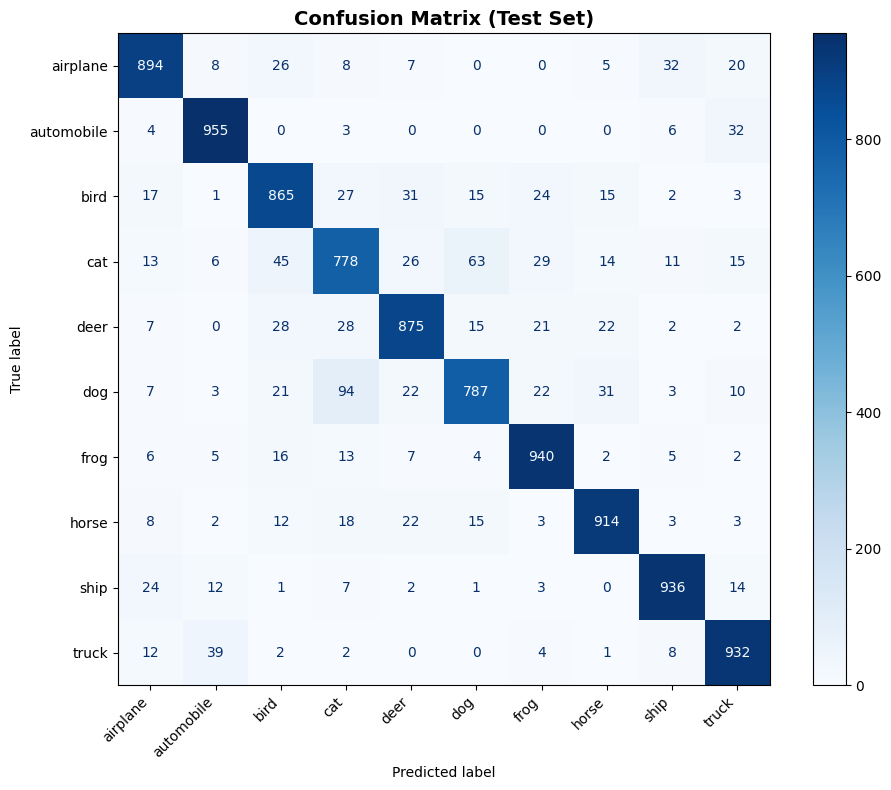


Per-Class Accuracy:
  airplane     0.8940
  automobile   0.9550
  bird         0.8650
  cat          0.7780
  deer         0.8750
  dog          0.7870
  frog         0.9400
  horse        0.9140
  ship         0.9360
  truck        0.9320


In [14]:
cm_test = confusion_matrix(y_true_test, y_pred_test)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=class_names)
disp.plot(ax=ax, colorbar=True, cmap='Blues', values_format='d')
plt.title('Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

per_class_acc = cm_test.diagonal() / cm_test.sum(axis=1)
print("\nPer-Class Accuracy:")
for i, class_name in enumerate(class_names):
    print(f"  {class_name:<12} {per_class_acc[i]:.4f}")

## Load Saved Model for Verification

Please use the code below to verify the the saved model.

In [9]:
import numpy as np
from keras.models import load_model

data = np.load('cifar10_clean.npz')

X_test = data['X_test'].astype('float32') / 255.0
y_test = data['y_test'].astype('float32')

model = load_model('best_model_v4_final.keras')

results = model.evaluate(X_test, y_test, verbose=1)

for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8876 - loss: 0.5077 - precision: 0.8947 - recall: 0.8843
loss: 0.5077
compile_metrics: 0.8876


## References

Geeks for Geeks. (2026, June 11). Hyperparameter Tuning. Retrieved from Geeks for Geeks: https://www.geeksforgeeks.org/machine-learning/hyperparameter-tuning/